In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from glob import glob
from sklearn.metrics import mean_squared_error

import warnings 
warnings.filterwarnings('ignore') 

sys.path.append("../../")
import stan

In [2]:
sample_list = ["1142243F", "1160920F", "CID4290", "CID4535", "CID4465", "CID44971"]

## Loading ST dataset
The spatially resolved transcriptomics data from [this paper](https://www.nature.com/articles/s41588-021-00911-1) are available from the [Zenodo data repository](https://doi.org/10.5281/zenodo.4739739). 

In [3]:
adatas = dict()
for sample in sample_list:
    adatas[sample] = sc.read_h5ad("results_breast/breast_st_raw/{}.h5ad".format(sample))
adatas

{'1142243F': AnnData object with n_obs × n_vars = 4784 × 28402
     obs: 'in_tissue', 'array_row', 'array_col', 'subtype', 'pathology', 'sample', 'replicate', 'ER', 'HER2', 'PR'
     uns: 'spatial'
     obsm: 'spatial'
     layers: 'raw_counts'}

We perform some basic filtering of genes and spots.

In [4]:
for sample in sample_list:
    adatas[sample] = adatas[sample][adatas[sample].obs['pathology'] != "Artefact"]
    adatas[sample] = adatas[sample][adatas[sample].obs['pathology'] != "Uncertain"]
    adatas[sample] = adatas[sample][adatas[sample].obs['pathology'] != np.nan]
    
    sc.pp.filter_genes(adatas[sample], min_cells=5)
    sc.pp.filter_cells(adatas[sample], min_counts=500)
adatas

{'1142243F': AnnData object with n_obs × n_vars = 4636 × 19372
     obs: 'in_tissue', 'array_row', 'array_col', 'subtype', 'pathology', 'sample', 'replicate', 'ER', 'HER2', 'PR', 'n_counts'
     var: 'n_cells'
     uns: 'spatial'
     obsm: 'spatial'
     layers: 'raw_counts'}

Write the processed data to file.

In [5]:
!mkdir results_breast/breast_st_qc
for sample in sample_list:
    adatas[sample].write("results_breast/breast_st_qc/{}.h5ad".format(sample))

mkdir: results_breast/breast_st_qc: File exists


## Loading the gene-TF prior matrix

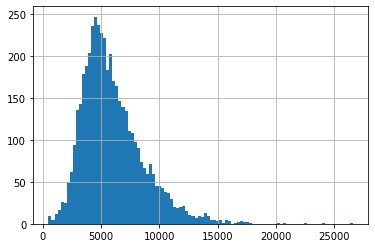

In [6]:
for sample in sample_list:
    adatas[sample].layers['raw'] = adatas[sample].X
    adatas[sample].obs['ncounts'] = adatas[sample].to_df('raw').T.sum()
    adatas[sample].obs['ncounts'].hist(bins=100)

In [7]:
for sample in sample_list:
    print(sample)
    adatas[sample] = stan.add_gene_tf_matrix(adatas[sample],
                                    min_cells_proportion = 0.2,
                                    min_tfs_per_gene= 5,
                                    min_genes_per_tf= 10,
                                    gene_tf_source="hTFtarget",
                                    tf_list="humantfs",
                                    source_dir="../data/gene_tf/")

    D = adatas[sample].varm['gene_tf']
    print('gene-TF matrix: {} x {}'.format(D.shape[0], D.shape[1]))
    print('min tfs associated with each gene: {}'.format(D.T.abs().sum().min()))
    print('min genes associated with each tf: {}'.format(D.abs().sum().min()))

    Y = adatas[sample].to_df()
    print('gene-cell matrix: {} x {}'.format(Y.shape[1], Y.shape[0]))
    print('min cells associated with each gene: {}'.format((Y>0).sum().min()))
    print('min genes associated with each cell: {}'.format((Y>0).T.sum().min()))

1142243F
gene-TF matrix: 4232 x 212
min tfs associated with each gene: 5
min genes associated with each tf: 10
gene-cell matrix: 4232 x 4636
min cells associated with each gene: 928
min genes associated with each cell: 297


## Computing the spatially dependent kernel

In [8]:
for sample in sample_list:
    print(sample)
    stan.pixel_intensity(adatas[sample], windowsize=25)
    stan.make_kernel(adatas[sample], n=250, im_feats_weight=0.25, bandwidth=0.2)

1142243F
Time elapsed: 0.31 seconds
Time elapsed: 7.11 seconds


In [9]:
for sample in sample_list:
    sc.pp.normalize_total(adatas[sample])
    adatas[sample].layers['scaled'] = np.sqrt(adatas[sample].to_df())

## GRN inference

In [10]:
for sample in sample_list:
    stan.assign_folds(adatas[sample], n_folds=10, random_seed=0)

### STAN

In [11]:
stan_models = dict()
for sample in sample_list:
    print(sample)
    stan_model = stan.Stan(adatas[sample], layer='scaled')
    stan_model.fit(n_steps=5, stages=1,
                  grid_search_params={'lam1':[1e-4, 1e4],'lam2':[1e-4, 1e4]})
    print(stan_model.params)
    stan_models[sample] = stan_model

1142243F
Time elapsed: 109.90 seconds
{'lam2': 0.0001, 'lam1': 10000.0}


Evaluate the cross validation performance using Pearsonr correlation coefficient.

In [12]:
for sample in sample_list:
    print(sample)
    stan_model = stan_models[sample]
    cor, gene_cor = stan_model.evaluate(fold=-1)
    print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
    print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))
    
    adatas[sample].obs['pred_cor_stan'] = cor
    adatas[sample].var['pred_cor_stan'] = gene_cor
    adatas[sample].obsm['tfa_stan'] = pd.DataFrame(stan_model.W_concat.T, 
                                                    index=adatas[sample].obs_names, 
                                                    columns=adatas[sample].uns['tf_names'])

1142243F
Spot-wise correlation:0.2194
Gene-wise correlation: 0.1066


Evaluate the validation performance using mean squared error.

In [13]:
for sample in sample_list:
    stan_model = stan_models[sample]
    Y = adatas[sample].varm['gene_tf'].dot(stan_model.W_concat)
    mean_squared_error(Y, adatas[sample].to_df('scaled').T)

### Ridge

In [14]:
ridge_models = dict()
for sample in sample_list:
    print(sample)
    ridge_model = stan.Ridge(adatas[sample], layer='scaled')
    ridge_model.fit(n_steps=5, stages=1,
                    grid_search_params={'lam':[1e-4, 1e4]})
    print(ridge_model.params)
    ridge_models[sample] = ridge_model

1142243F
Time elapsed: 22.17 seconds
{'lam': 0.0001}


In [15]:
for sample in sample_list:
    print(sample)
    ridge_model = ridge_models[sample]
    cor, gene_cor = ridge_model.evaluate(fold=-1)
    print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
    print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))
    
    adatas[sample].obs['pred_cor_ridge'] = cor
    adatas[sample].var['pred_cor_ridge'] = gene_cor
    adatas[sample].obsm['tfa_ridge'] = pd.DataFrame(ridge_model.W_concat.T, 
                                                    index=adatas[sample].obs_names, 
                                                    columns=adatas[sample].uns['tf_names'])

1142243F
Spot-wise correlation:0.2008
Gene-wise correlation: 0.0694


In [16]:
for sample in sample_list:
    ridge_model = ridge_models[sample]
    Y = adatas[sample].varm['gene_tf'].dot(ridge_model.W_concat)
    mean_squared_error(Y, adatas[sample].to_df('scaled').T)

In [17]:
!mkdir results_breast/breast_st_stan
for sample in sample_list:
    adatas[sample].write("results_breast/breast_st_stan/{}.h5ad".format(sample))